## Fase 2: Entendimento dos Dados

Nesta fase, exploramos o conjunto de dados para entender sua estrutura, qualidade e distribuição. Buscamos por valores faltantes, tipos de dados inconsistentes e a distribuição das variáveis.


In [ ]:
#pip install upsetplot

In [8]:
#importando as bibliotecas
from exploratory_data_analysis import return_data, generic_info, null_values, duplicated_values
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from upsetplot import UpSet, from_memberships
import warnings

warnings.filterwarnings(
    "ignore",
    module="upsetplot"
)

In [2]:
# Leitura dos dados
df = return_data('contents/telecom_churn.csv')

df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [3]:
# avaliando as informações gerais do dataset

generic_info(df)

O dataset tem o shape de 3333 linhas e 11 colunas
--------------------------------------------------
As colunas  obtém os seguintes dados de máximo e mínimo:

Churn: (np.int64(0), np.int64(1))
AccountWeeks: (np.int64(1), np.int64(243))
ContractRenewal: (np.int64(0), np.int64(1))
DataPlan: (np.int64(0), np.int64(1))
DataUsage: (np.float64(0.0), np.float64(5.4))
CustServCalls: (np.int64(0), np.int64(9))
DayMins: (np.float64(0.0), np.float64(350.8))
DayCalls: (np.int64(0), np.int64(165))
MonthlyCharge: (np.float64(14.0), np.float64(111.3))
OverageFee: (np.float64(0.0), np.float64(18.19))
RoamMins: (np.float64(0.0), np.float64(20.0))


* verificando como os valores estão distribuídos e categorizados nas colunas

* Temos:
  * 3333 linhas que podem ser lidas como clientes
  * Todas as colunas apresentam valores preenchidos variando entre os tipos inteiros e reais
  * Algumas colunas estão tratadas de forma numérica mas representam valores categóricos como o SIM ou NÃO (Churn, ContractTRenewal, DataPlan)

In [4]:
# checando a questão dos valores nulos
null_values(df)

Não existem valores nulos no dataset
Não existem valores nulos no dataset
Não existem valores nulos no dataset
Não existem valores nulos no dataset
Não existem valores nulos no dataset
Não existem valores nulos no dataset
Não existem valores nulos no dataset
Não existem valores nulos no dataset
Não existem valores nulos no dataset
Não existem valores nulos no dataset
Não existem valores nulos no dataset


In [9]:
# verificando se existem valores duplicados
duplicated_values(df)

Churn - 3331 valores duplicados
AccountWeeks - 3121 valores duplicados
ContractRenewal - 3331 valores duplicados
DataPlan - 3331 valores duplicados
DataUsage - 3159 valores duplicados
CustServCalls - 3323 valores duplicados
DayMins - 1666 valores duplicados
DayCalls - 3214 valores duplicados
MonthlyCharge - 2706 valores duplicados
OverageFee - 2309 valores duplicados
RoamMins - 3171 valores duplicados


É possível observar que há uma diferença em relação ao intervalo encontrado nas features. Isso indica a necessidade de normalização.

* Analisando a distribuição dos dados

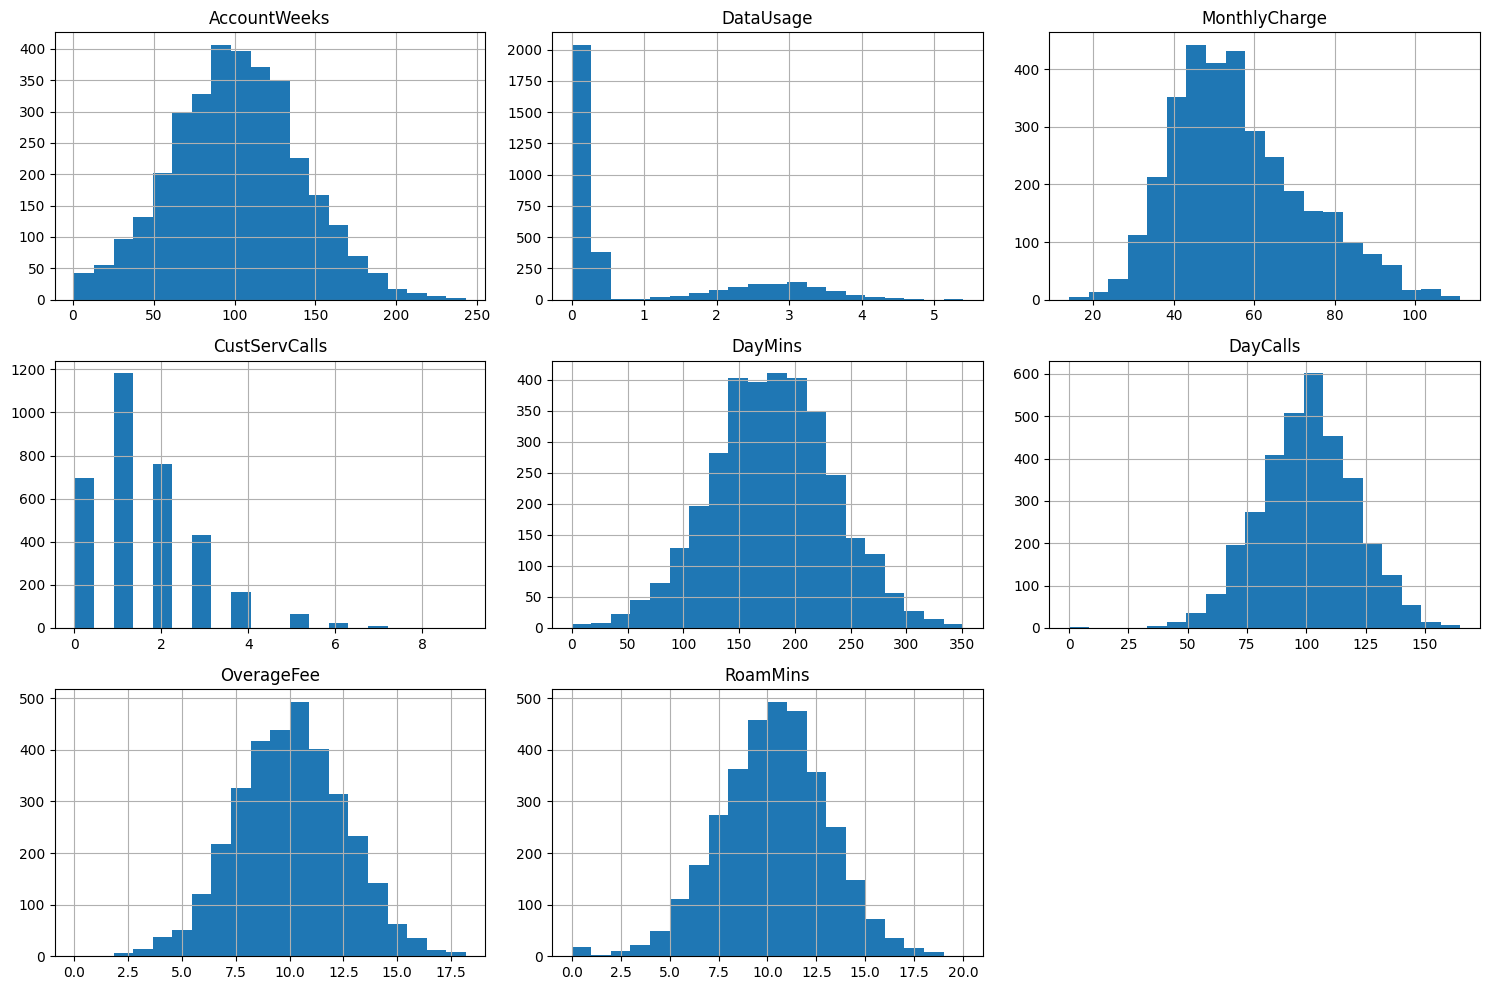

In [51]:
df_dist = df[['AccountWeeks','DataUsage','MonthlyCharge','CustServCalls','DayMins','DayCalls','OverageFee','RoamMins']].copy()
df_dist.hist(bins=20, figsize=(15, 10), layout=(3, 3), grid=True)
plt.tight_layout()
plt.show()

Observações:
  1. Podemos observar que a maioria dos dados apresentam uma distribuição aproximadamente normal. Isto indica que iremos padronizá-los.
  2. Para a feature de data usage vemos que a quantidade de dados utilizados se concentra mais no intervalo de 0 a 0.5 GB. Ou seja, não há tanto uso de dados nestes clientes podendo ser uma parcela a ser investigada.

* Analisando o perfil do usuário sobre o churn

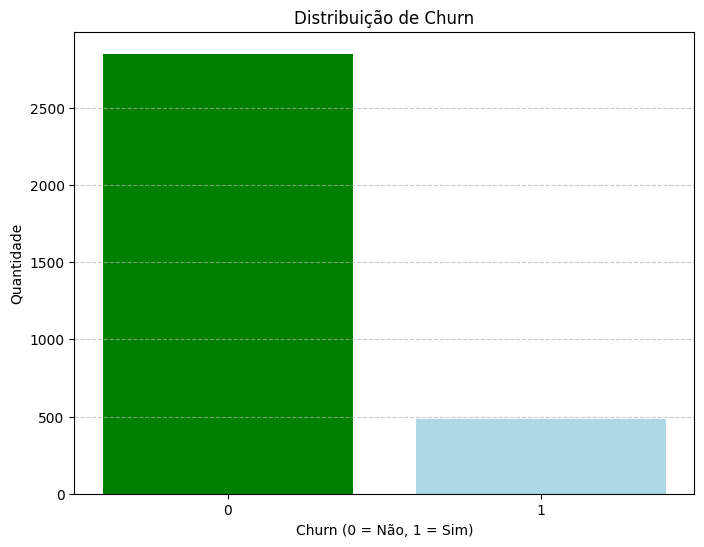

In [52]:
df_vis_churn = df['Churn'].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(df_vis_churn.index.astype(str), df_vis_churn.values, color=['green', 'lightblue'])

plt.title('Distribuição de Churn')
plt.xlabel('Churn (0 = Não, 1 = Sim)')
plt.ylabel('Quantidade')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Existem muitos mais casos sem churn. Ou seja, os dados estão desbalanceados e irá influenciar no treinamento do modelo.

In [53]:
# Grupo de pessoas a partir da renovação de contrato recente
df_vis_churn = df.groupby(['ContractRenewal','Churn'])['Churn'].count()
df_vis_churn

ContractRenewal  Churn
0                0         186
                 1         137
1                0        2664
                 1         346
Name: Churn, dtype: int64

A quantidade de pessoas que fizeram uma renovação recente e efetuaram o churn é bem maior do que as pessoas que não renovaram recentemente. Isto pode indicar que talvez após a renovação possa ter ocorrido algum fator que influenciou a saída, por exemplo, o aumento da fatura.

In [54]:
# Grupo de pessoas com plano de dados
df_vis_churn = df.groupby(['DataPlan','Churn'])['Churn'].count()
df_vis_churn

DataPlan  Churn
0         0        2008
          1         403
1         0         842
          1          80
Name: Churn, dtype: int64

As pessoas sem plano de dados efetuam mais o churn do que as pessoas com plano de dados. Ou seja, indica que talvez a medida que o uso de dados vá aumentando e não há um plano que cubra este consumo, o que está relacionado a fatura ou disponibilidade dos dados, as pessoas vão efetuando a saída da base.

In [55]:
# Analisando as classificações de renovação de contrato, plano de dados e churn ao mesmo tempo

# dataplan -> 0 = não, 1 = sim
# contractrenewal -> 0 = não, 1 = sim
# churn -> 0 = não, 1 = sim

df_vis_churn = df.groupby(['ContractRenewal','DataPlan','Churn'])['Churn'].count()
df_vis_churn

ContractRenewal  DataPlan  Churn
0                0         0         130
                           1         101
                 1         0          56
                           1          36
1                0         0        1878
                           1         302
                 1         0         786
                           1          44
Name: Churn, dtype: int64

Analisando a intersecção entre os conjuntos de renovação de contrato, churn e plano de dados

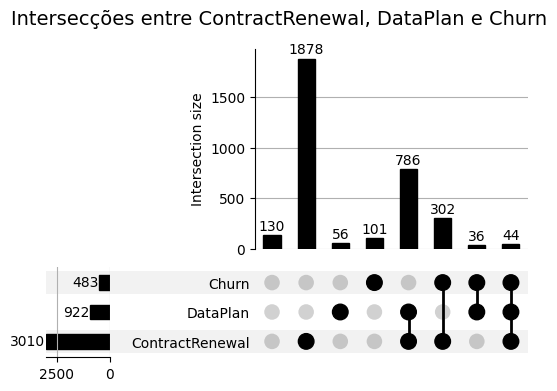

In [56]:
df_vis_churn = (
    df
    .groupby(['ContractRenewal', 'DataPlan', 'Churn'])
    .size()
    .reset_index(name='count')
)

memberships = []
counts = []

for _, row in df_vis_churn.iterrows():
    m = []

    if row['ContractRenewal'] == 1:
        m.append('ContractRenewal')

    if row['DataPlan'] == 1:
        m.append('DataPlan')

    if row['Churn'] == 1:
        m.append('Churn')

    memberships.append(m)
    counts.append(row['count'])


upset_data = from_memberships(
    memberships,
    data=counts
)


UpSet(
    upset_data,
    subset_size='sum',
    show_counts=True,
    sort_by='degree'
).plot()

plt.suptitle(
    'Intersecções entre ContractRenewal, DataPlan e Churn',
    fontsize=14
)

plt.show()


A maioria da base renovou o contrato (3010 clientes)

Mesmo renovando contrato:

  * 302 efetuaram o churn sem plano de dados
  * 44 efetuaram o churn mesmo com plano de dados. O que chama atenção, pois este grupo, teoricamente, já recebeu dois incentivos de retenção mas mesmo assim saiu do contrato.

Clientes sem renovação têm churn relativamente alto (101 + 36)

* Analises complementares

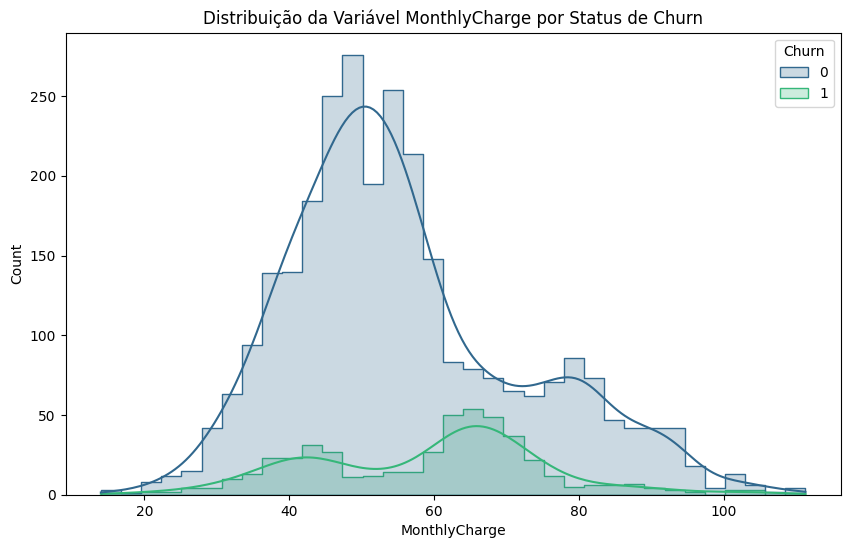

In [57]:
# Analisando a hipótese se o valor da fatura tem algum impacto no churn
plt.figure(figsize=(10, 6))
# O parâmetro 'hue' faz todo o trabalho de separar 0 de 1
sns.histplot(data=df, x='MonthlyCharge', hue='Churn', kde=True, element="step", palette='viridis')
plt.title('Distribuição da Variável MonthlyCharge por Status de Churn')
plt.show()

Temos uma concentração maior de churn no intervalo de fatura entre 60 a 80. Algo que não é visto se compararmos com o grupo sem churn que se concentra entre 40 a 60 em termos de fatura.

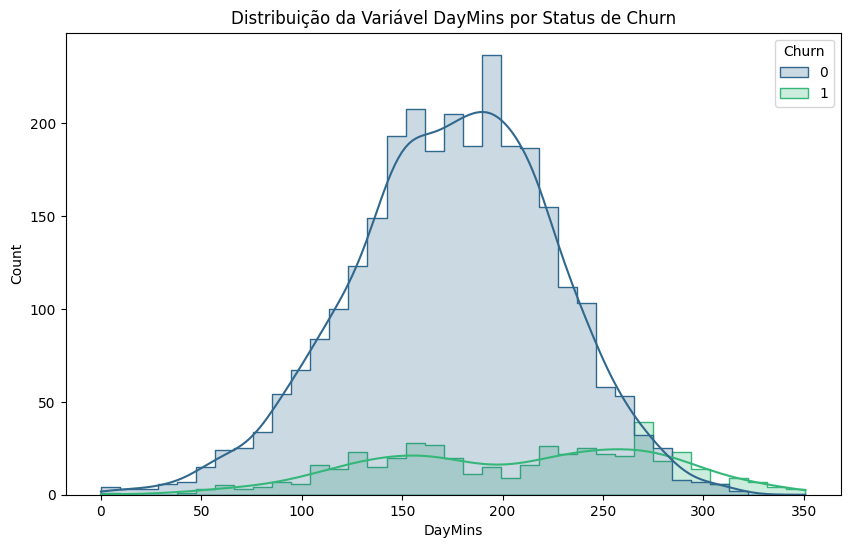

In [58]:
# Verificando a relação do uso de minutos
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='DayMins', hue='Churn', kde=True, element="step", palette='viridis')
plt.title('Distribuição da Variável DayMins por Status de Churn')
plt.show()

É possível observar que há uma concentração maior em relação a média de minutos dos clientes que efetuaram churn nos valores acima de 200.

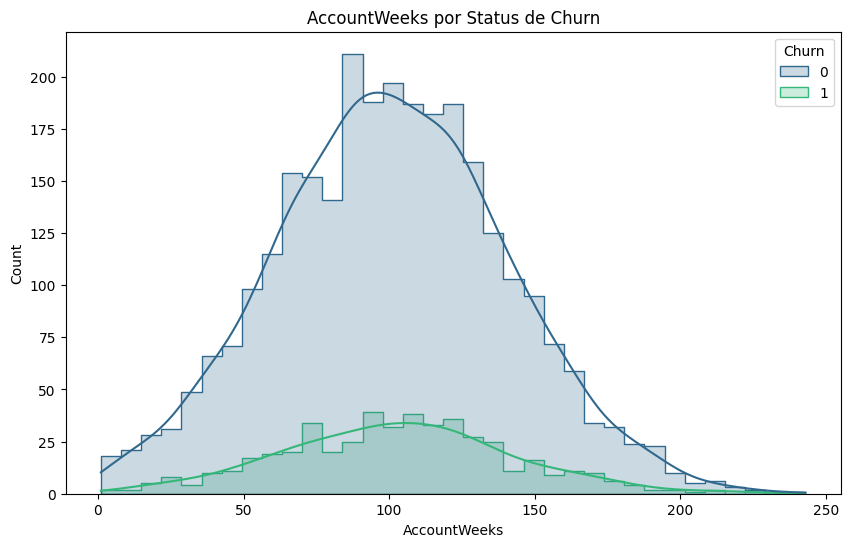

In [59]:
# Verificando a relação da quantidade de semanas ativas e o churn
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='AccountWeeks', hue='Churn', kde=True, element="step", palette='viridis')
plt.title('AccountWeeks por Status de Churn')
plt.show()

Os usuários que efetuam churn estão concentrados no intervalo de 50 a 150 semanas ativas.

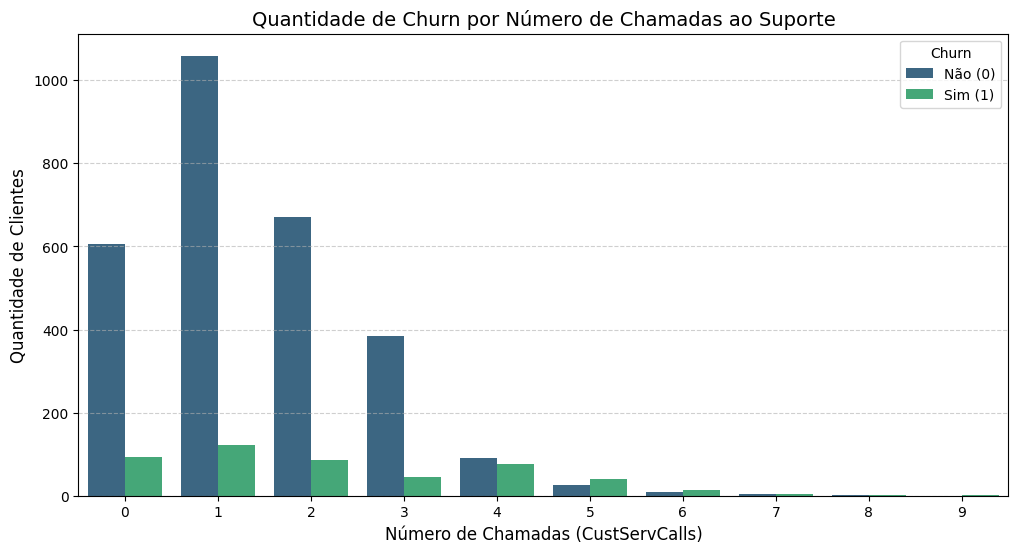

In [60]:
# Analisando a quantidade de chamadas efetuadas ao suporte e o status de churn
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='CustServCalls', hue='Churn', palette='viridis')

plt.title('Quantidade de Churn por Número de Chamadas ao Suporte', fontsize=14)
plt.xlabel('Número de Chamadas (CustServCalls)', fontsize=12)
plt.ylabel('Quantidade de Clientes', fontsize=12)
plt.legend(title='Churn', labels=['Não (0)', 'Sim (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

As pessoas que realizam o cancelamento efetuam mais ligações acima de 4 vezes. Talvez, elas não estão conseguindo solucionar algum tipo de problema e por ter tentado mais de 4 vezes resolvem desistir do contrato.